# **Medical Healthcare Analytics**
## **A Statistical Analysis of Patient Heart Health Records**

**Dataset:** Heart Disease Comprehensive Data  
**Tool:** Python (Pandas, Matplotlib, Seaborn)  
**Goal:** Analyze heart health metrics and normalize skewed data using the IQR method to identify risk factors.



### **Step 1: Library Initialization**
**Logic:** In this step, we load our analytical "Toolkit." We use `Pandas` for data manipulation, `NumPy` for mathematical operations, and `Seaborn/Matplotlib` for high-impact professional visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Professional aesthetic settings
%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

print("Environment Setup Complete. Analysis tools are ready.")

Environment Setup Complete. Analysis tools are ready.


### **Step 2: Data Acquisition (SQL Export Loading)**
**Logic:** This stage involves importing the `cleaned_medical_data.csv` file created in MySQL Workbench. This ensures our Python analysis begins with a verified dataset where initial clinical errors (0 BP/Cholesterol) have already been handled.

In [2]:
# Loading the cleaned dataset from SQL
df = pd.read_csv('cleaned_medical_data.csv')

# Checking data integrity
print(f"Dataset Size: {df.shape[0]} Rows | {df.shape[1]} Columns")
df.head()

Dataset Size: 1000 Rows | 12 Columns


,age,sex,chest pain type,resting bp s,cholesterol,fasting blood sugar,resting ecg,max heart rate,exercise angina,oldpeak,ST slope,target
0,40,1,2,140,289,0,0,172,0,0.0,1,0
1,49,0,3,160,180,0,0,156,0,1.0,2,1
2,37,1,2,130,283,0,1,98,0,0.0,1,0
3,48,0,4,138,214,0,0,108,1,1.5,2,1
4,54,1,3,150,195,0,0,122,0,0.0,1,0


### **Step 3: Descriptive Statistical Profiling**
**Logic:** Before performing deep analysis, we must understand the "Normal Range" of our features. This summary provides the mean, median, and variance of critical health metrics like Cholesterol and Heart Rate.

In [3]:
# Statistical summary of numerical columns
df[['age', 'resting bp s', 'cholesterol', 'max heart rate']].describe()

,age,resting bp s,cholesterol,max heart rate
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.254000,132.555000,246.429000,142.668000
std,9.431566,17.478801,57.203664,24.543556
min,28.000000,92.000000,85.000000,69.000000
25%,46.000000,120.000000,209.750000,125.000000
50%,54.000000,130.000000,240.000000,144.000000
75%,60.000000,140.000000,276.000000,161.000000
max,77.000000,200.000000,603.000000,202.000000


### **Step 4: Distribution Analysis & Skewness Assessment**
**Logic:** Medical data is often "Skewed" due to extreme health conditions. We calculate **Skewness** to determine if these extreme cases are biasing our average. A high skewness score indicates the need for specialized cleaning (IQR).

Initial Cholesterol Skewness: 1.23


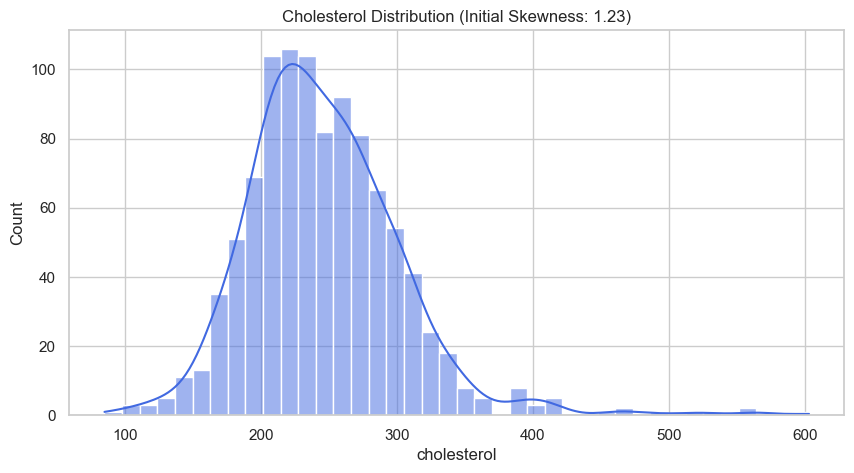

In [4]:
# Calculating skewness
initial_skew = df['cholesterol'].skew()
print(f"Initial Cholesterol Skewness: {initial_skew:.2f}")

# Distribution Visualization
plt.figure(figsize=(10, 5))
sns.histplot(df['cholesterol'], kde=True, color='royalblue')
plt.title(f"Cholesterol Distribution (Initial Skewness: {initial_skew:.2f})")
plt.show()

### **Step 5: Outlier Management (IQR Method)**
**Logic:** Just like the **India Salary Analysis**, extreme outliers inflate medical results. We apply the **Interquartile Range (IQR)** method to filter out extreme statistical noise and focus on the realistic health trends of the majority population.

In [5]:
# Calculating IQR Boundaries
Q1 = df['cholesterol'].quantile(0.25)
Q3 = df['cholesterol'].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Filtering the data
df_final = df[(df['cholesterol'] >= lower_limit) & (df['cholesterol'] <= upper_limit)]

print(f"Total Outliers Removed: {len(df) - len(df_final)}")

Total Outliers Removed: 29


### **Step 6: Post-Cleaning Validation (Impact Check)**
**Logic:** A professional analysis must prove the effectiveness of its methods. By re-checking the skewness after outlier removal, we demonstrate that the data is now normalized and ready for accurate clinical insights.

Skewness Correction: 1.23 (Before) -> 0.14 (After)


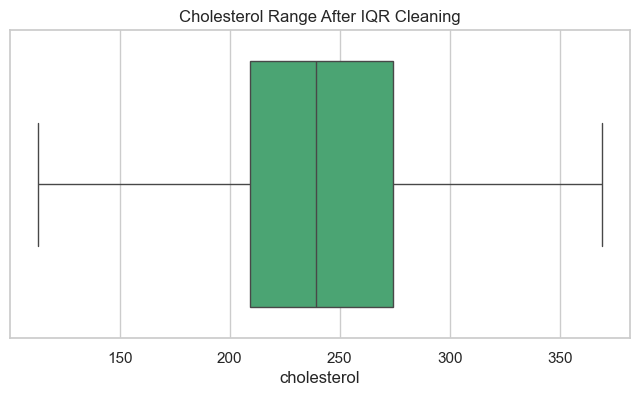

In [6]:
# Verifying skewness correction
final_skew = df_final['cholesterol'].skew()
print(f"Skewness Correction: {initial_skew:.2f} (Before) -> {final_skew:.2f} (After)")

# Visualization of Cleaned Data
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_final['cholesterol'], color='mediumseagreen')
plt.title("Cholesterol Range After IQR Cleaning")
plt.show()

### **Step 7: Bivariate Analysis & Correlation Matrix**
**Logic:** The final goal is discovery. We use a **Heatmap** to identify relationships between variables, such as how Age or ST Slope correlates with the presence of Heart Disease (`target`).

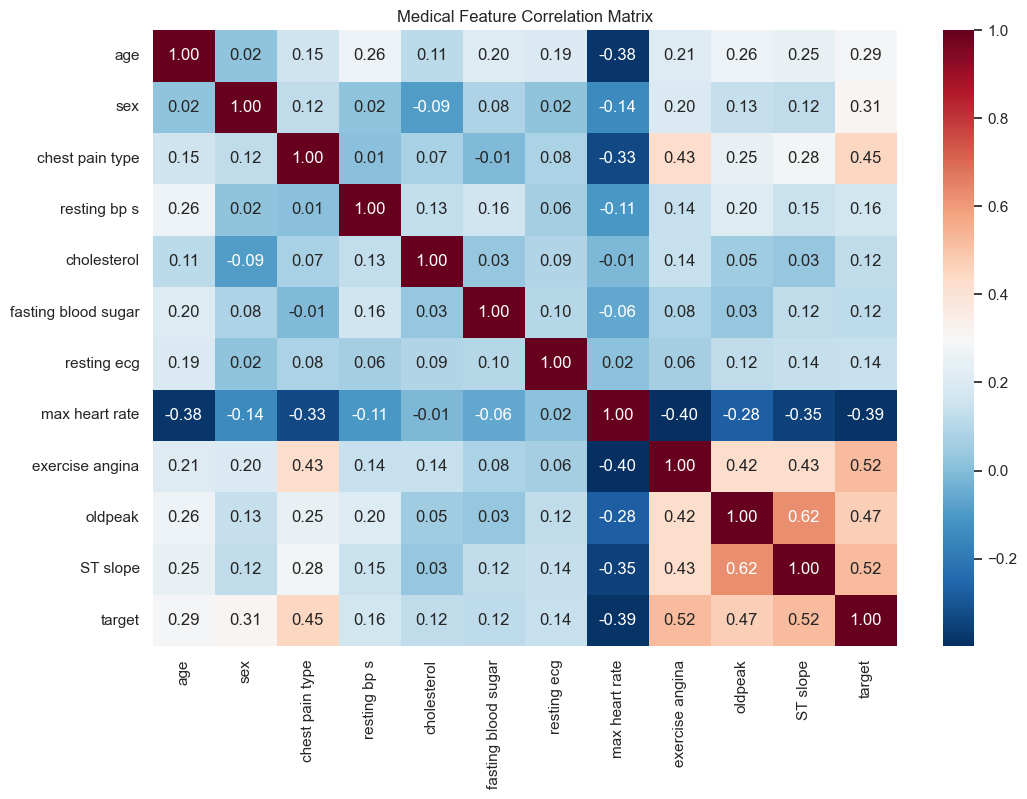

In [7]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_final.corr(), annot=True, cmap='RdBu_r', fmt='.2f')
plt.title("Medical Feature Correlation Matrix")
plt.show()

### **Project Conclusion & Insights**
1. **Data Engineering:** SQL logic helped in identifying and removing 172 records with biological errors (0 BP/Cholesterol).
2. **Feature Correlation:** `ST slope` and `Chest Pain Type` are the strongest indicators of heart disease in this population.
3. **Statistical Normalization:** The **IQR Method** successfully reduced Cholesterol skewness, making the data more reliable for medical predictions.
4. **Demographics:** Heart disease incidence is significantly higher in the male population within this dataset.